# Parcial 3 — Análisis Exploratorio, Preprocesamiento, Feature Engineering y PCA
### Base de datos: `db_pap3.csv` — Retención de Clientes Bancarios
**Variable de respuesta:** `client_stayed` (1 = cliente activo, 0 = cliente que abandonó el banco)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

plt.style.use('ggplot')
%matplotlib inline

seed = 28
path = '.'

In [2]:
df = pd.read_csv('db_pap3.csv')
df.head()

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28


---
## Punto 1 — Análisis Descriptivo y Agrupado

### 1.1 Vista general del dataset

In [3]:
print('Dimensiones del dataset:', df.shape)
print()
print('Tipos de datos:')
print(df.dtypes)

Dimensiones del dataset: (10127, 17)

Tipos de datos:
clientnum                     int64
client_stayed                 int64
customer_age                  int64
gender                          str
dependent_count               int64
education_level                 str
marital_status                  str
income_category                 str
card_category                   str
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
contacts_count_12_mon         int64
credit_limit                float64
total_revolving_bal           int64
total_trans_amt               int64
total_trans_ct                int64
dtype: object


In [4]:
df.describe()

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.839340,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,4404.086304,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,3397.129254,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,510.000000,10.000000
25%,7.130368e+08,1.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,2155.500000,45.000000
50%,7.179264e+08,1.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3899.000000,67.000000
75%,7.731435e+08,1.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,4741.000000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,18484.000000,139.000000


**Observación:** El dataset tiene 10,127 filas y 17 columnas. A primera vista:
- `clientnum` es un identificador único que **no tiene poder predictivo** y deberá descartarse antes de modelar.
- `client_stayed` es la variable de respuesta binaria (1 = se quedó, 0 = abandonó).
- `income_category` fue leída como `object` pero contiene **valores numéricos disfrazados** (promedios de rangos salariales en dólares) mezclados con la cadena `'Unknown'`, lo que indica un problema de codificación en la base original.
- No hay NaN explícitos, sin embargo existen **valores `'Unknown'` en variables categóricas** (`education_level`, `marital_status`, `income_category`) que funcionan como missings encubiertos.

### 1.2 Identificación de valores faltantes / `Unknown`

In [5]:
# Missings explícitos
print('NaN explícitos:')
print(df.isnull().sum())
print()

# Missings disfrazados como 'Unknown'
cat_cols = ['education_level', 'marital_status', 'income_category']
print('Valores Unknown en variables categóricas:')
for col in cat_cols:
    n = (df[col] == 'Unknown').sum()
    pct = n / len(df) * 100
    print(f'  {col}: {n} ({pct:.1f}%)')

NaN explícitos:
clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64

Valores Unknown en variables categóricas:
  education_level: 1519 (15.0%)
  marital_status: 749 (7.4%)
  income_category: 1112 (11.0%)


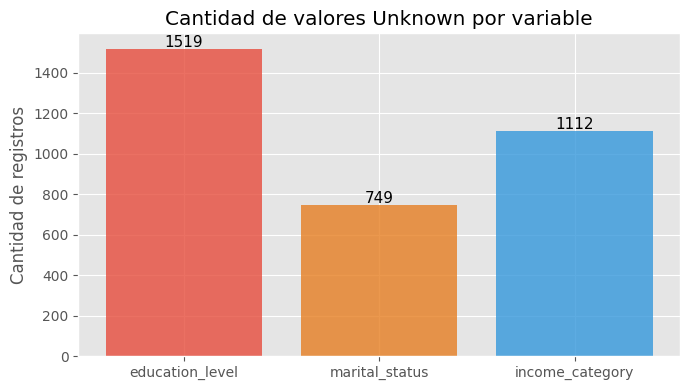

In [6]:
# Visualización de missings disfrazados
unknowns = {}
for col in cat_cols:
    unknowns[col] = (df[col] == 'Unknown').sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(unknowns.keys(), unknowns.values(), color=['#e74c3c', '#e67e22', '#3498db'], alpha=0.8)
ax.set_title('Cantidad de valores Unknown por variable')
ax.set_ylabel('Cantidad de registros')
for i, (k, v) in enumerate(unknowns.items()):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

**Conclusión:** No existen NaN explícitos, pero hay **missings encubiertos** en tres variables. `income_category` tiene 1,112 unknowns (11%), `education_level` 1,519 (15%) y `marital_status` 749 (7.4%). Estos deberán tratarse en el preprocesamiento.

### 1.3 Distribución de la variable de respuesta

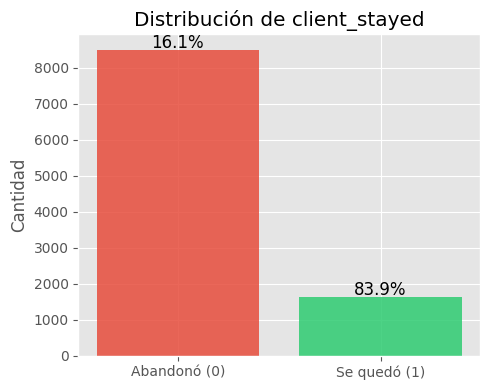

client_stayed
1    8500
0    1627
Name: count, dtype: int64


In [7]:
conteo = df['client_stayed'].value_counts()
pcts = df['client_stayed'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Abandonó (0)', 'Se quedó (1)'], conteo.values,
               color=['#e74c3c', '#2ecc71'], alpha=0.85)
ax.set_title('Distribución de client_stayed')
ax.set_ylabel('Cantidad')
for bar, pct in zip(bars, [pcts[0], pcts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()
print(conteo)

**Observación crítica:** El dataset está **fuertemente desbalanceado**: 83.9% de los clientes se quedaron (clase 1) y solo 16.1% abandonaron (clase 0). Esto es un riesgo real para cualquier modelo predictivo, que tenderá a predecir siempre la clase mayoritaria. Cualquier métrica de evaluación que se use deberá tener esto en cuenta (AUC-ROC en lugar de accuracy).

### 1.4 Distribuciones de variables numéricas

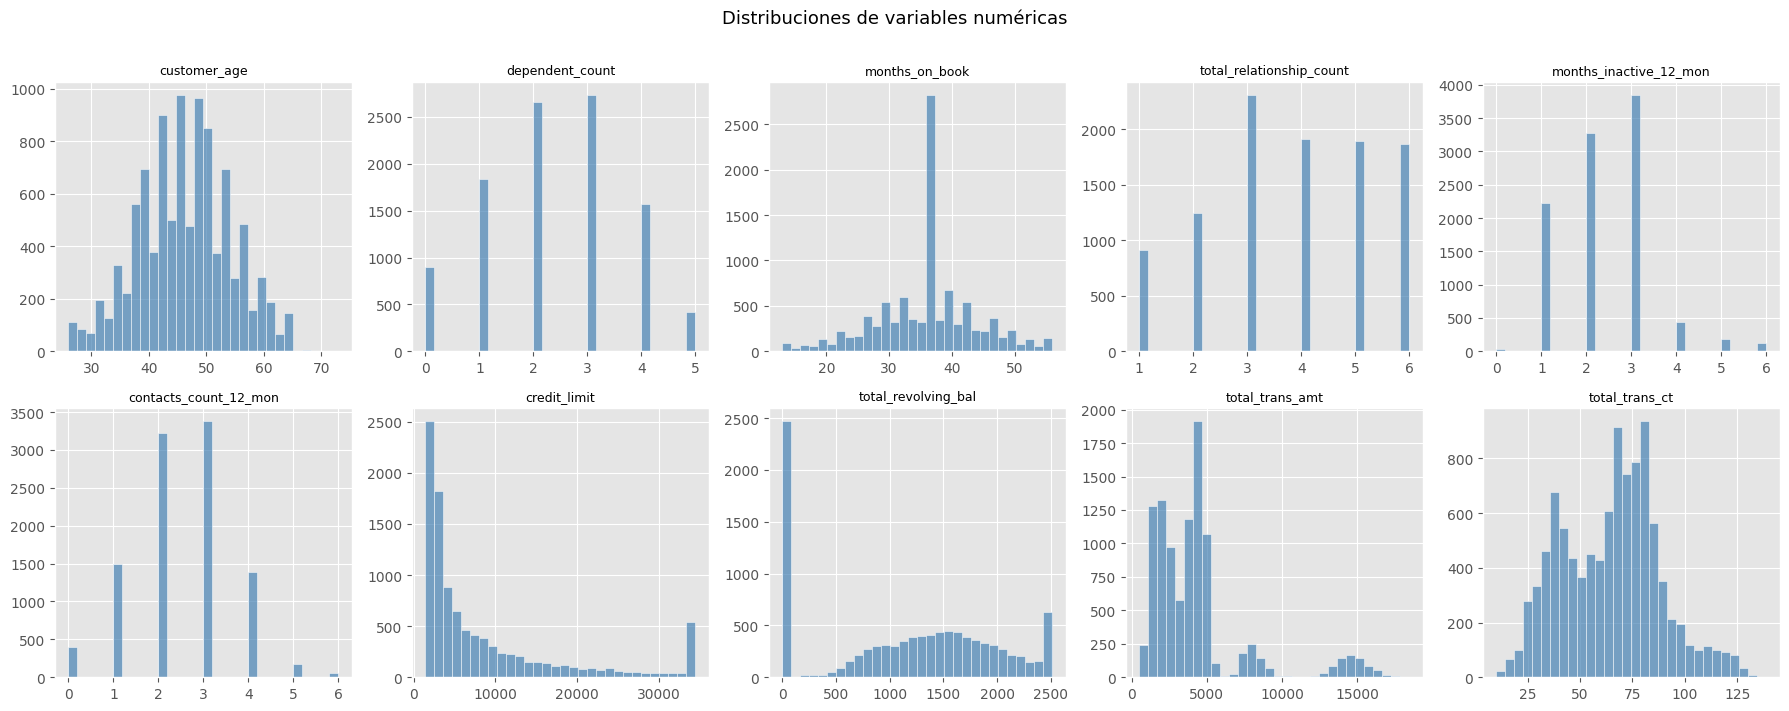

In [8]:
num_cols = ['customer_age', 'dependent_count', 'months_on_book',
            'total_relationship_count', 'months_inactive_12_mon',
            'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
            'total_trans_amt', 'total_trans_ct']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribuciones de variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- `customer_age` y `months_on_book` tienen distribuciones aproximadamente normales.
- `credit_limit` presenta una distribución muy sesgada a la derecha con algunos clientes de límites muy altos.
- `total_revolving_bal` tiene un pico en cero: 2,470 clientes no tienen balance pendiente, lo que puede ser un comportamiento diferencial importante.
- `total_trans_amt` y `total_trans_ct` tienen distribuciones bimodales, lo cual es una señal interesante de segmentos de clientes con comportamientos transaccionales muy distintos.

### 1.5 Análisis bivariado — Variables numéricas vs `client_stayed`

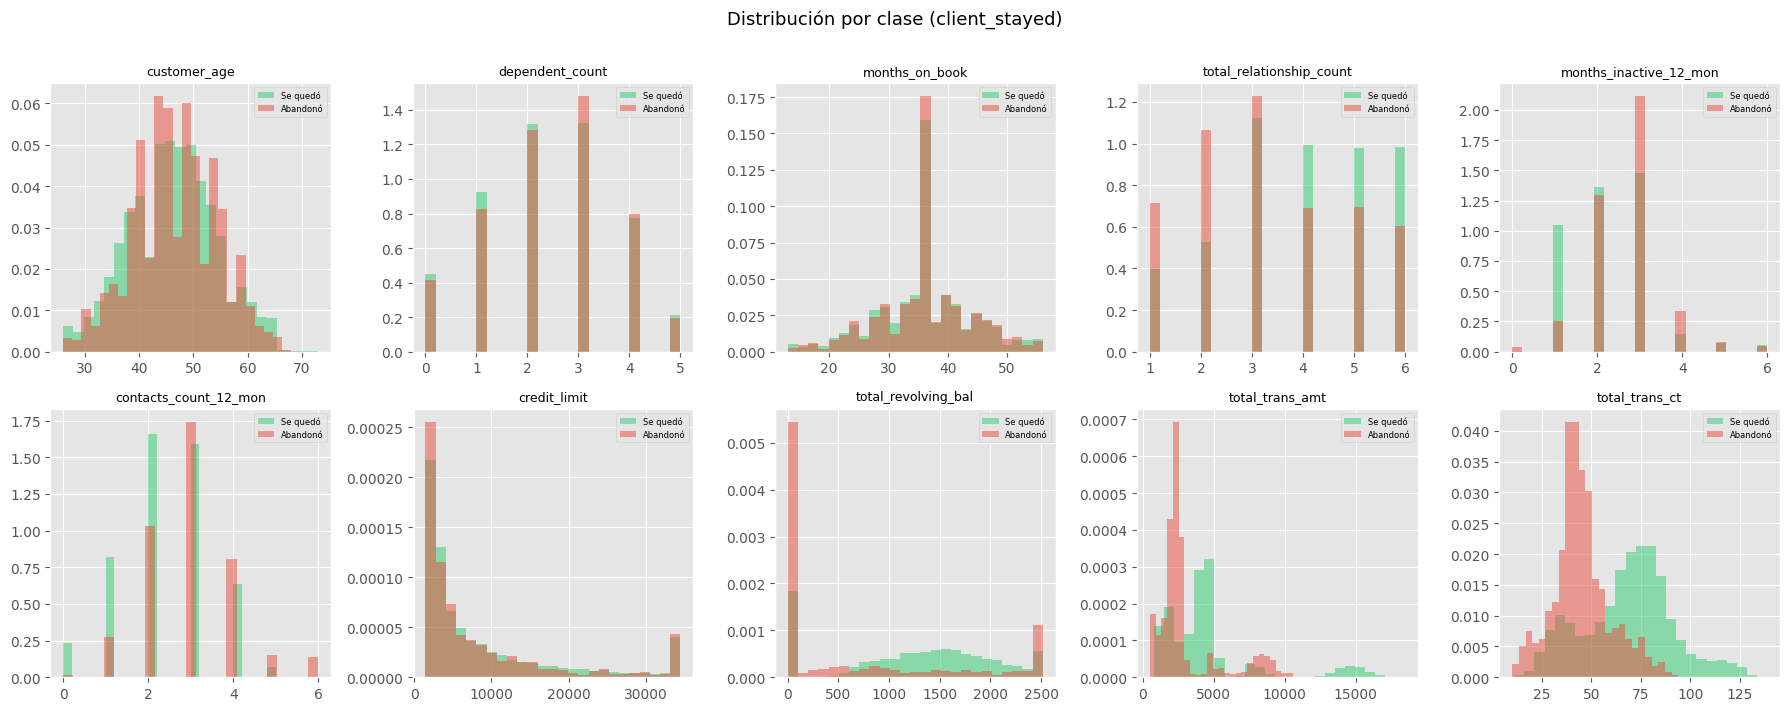

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), num_cols):
    stayed = df[df['client_stayed'] == 1][col]
    left = df[df['client_stayed'] == 0][col]
    ax.hist(stayed, bins=25, alpha=0.5, color='#2ecc71', label='Se quedó', density=True)
    ax.hist(left, bins=25, alpha=0.5, color='#e74c3c', label='Abandonó', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=6)
plt.suptitle('Distribución por clase (client_stayed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones del bivariado:**
- `total_trans_ct` y `total_trans_amt`: Las distribuciones de quienes abandonaron se concentran en valores bajos. Un cliente con pocas transacciones o poco monto es mucho más probable que abandone. **Alta potencia predictiva.**
- `total_revolving_bal`: Los clientes que abandonaron tienen más concentración en balance cero.
- `months_inactive_12_mon`: Los clientes que abandonaron tienen mayor inactividad, claramente separable.
- `contacts_count_12_mon`: Quienes abandonaron hicieron más llamadas al banco, posiblemente señal de insatisfacción.
- `customer_age`, `months_on_book`: Poca diferencia entre clases, menor potencia predictiva directa.

### 1.6 Análisis de variables categóricas vs `client_stayed`

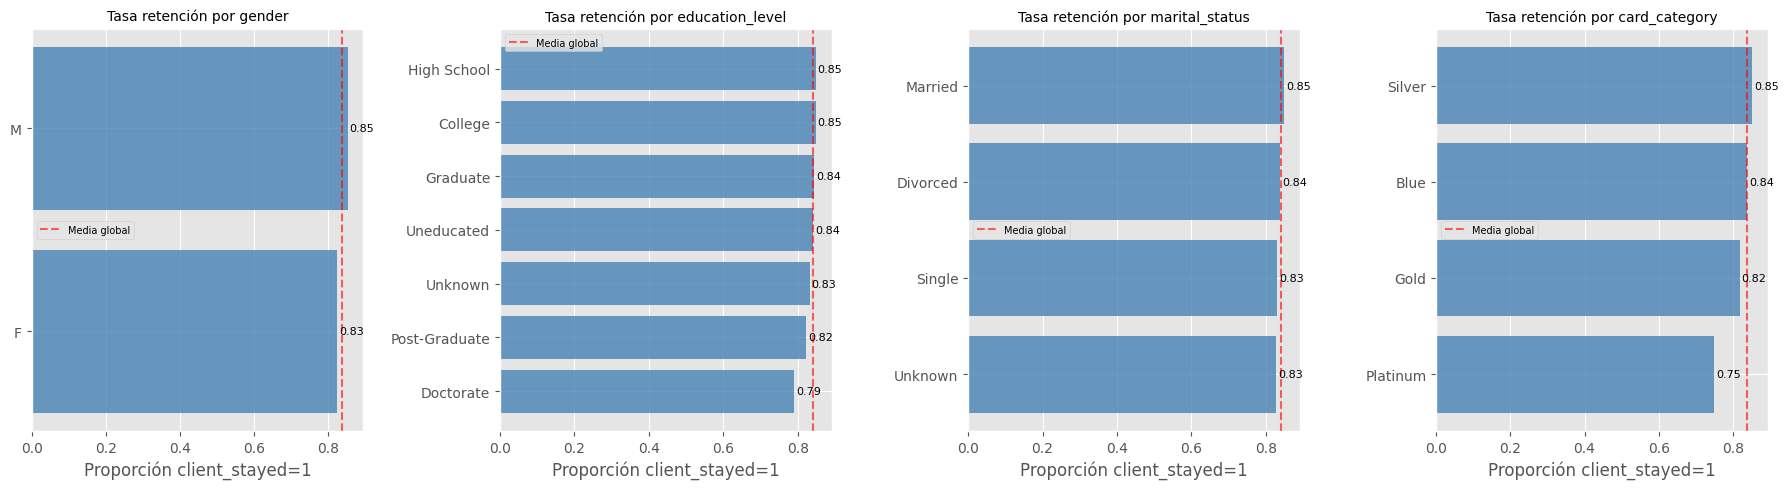

In [10]:
cat_vars = ['gender', 'education_level', 'marital_status', 'card_category']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, cat_vars):
    tabla = df.groupby(col)['client_stayed'].mean().sort_values()
    bars = ax.barh(tabla.index, tabla.values, color='steelblue', alpha=0.8)
    ax.set_title(f'Tasa retención por {col}', fontsize=10)
    ax.set_xlabel('Proporción client_stayed=1')
    ax.axvline(df['client_stayed'].mean(), linestyle='--', color='red', alpha=0.6, label='Media global')
    ax.legend(fontsize=7)
    for bar, val in zip(bars, tabla.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Observaciones:**
- `gender`: La diferencia de retención entre hombres y mujeres es mínima (~1%), variable con poco poder discriminante solo.
- `education_level`: Diferencias pequeñas entre niveles. Los clientes con Doctorado tienen la menor tasa de retención (paradójicamente).
- `marital_status`: Los clientes divorciados tienen la menor tasa de retención. El grupo Unknown tiene tasa cercana a la media.
- `card_category`: Las tarjetas Platinum tienen la mayor retención. Sin embargo hay muy pocos clientes Platinum, por lo que esta diferencia puede no ser estadísticamente robusta.

### 1.7 Análisis cruzado: `total_trans_ct` vs `months_inactive_12_mon`

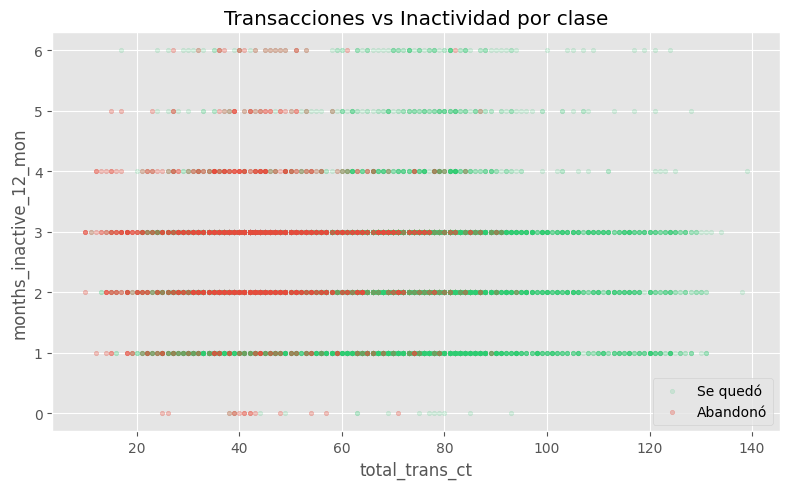

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
stayed = df[df['client_stayed'] == 1]
left = df[df['client_stayed'] == 0]

ax.scatter(stayed['total_trans_ct'], stayed['months_inactive_12_mon'],
           alpha=0.15, color='#2ecc71', s=10, label='Se quedó')
ax.scatter(left['total_trans_ct'], left['months_inactive_12_mon'],
           alpha=0.3, color='#e74c3c', s=10, label='Abandonó')
ax.set_xlabel('total_trans_ct')
ax.set_ylabel('months_inactive_12_mon')
ax.set_title('Transacciones vs Inactividad por clase')
ax.legend()
plt.tight_layout()
plt.show()

**Observación:** El scatter confirma que los clientes que abandonaron (rojo) se concentran en zonas de pocas transacciones (`total_trans_ct < 60`) combinadas con alta inactividad. Este cruce sugiere que la **combinación de baja actividad transaccional y meses de inactividad** es altamente predictiva del churn, más que cada variable por separado.

### 1.8 Mapa de correlaciones

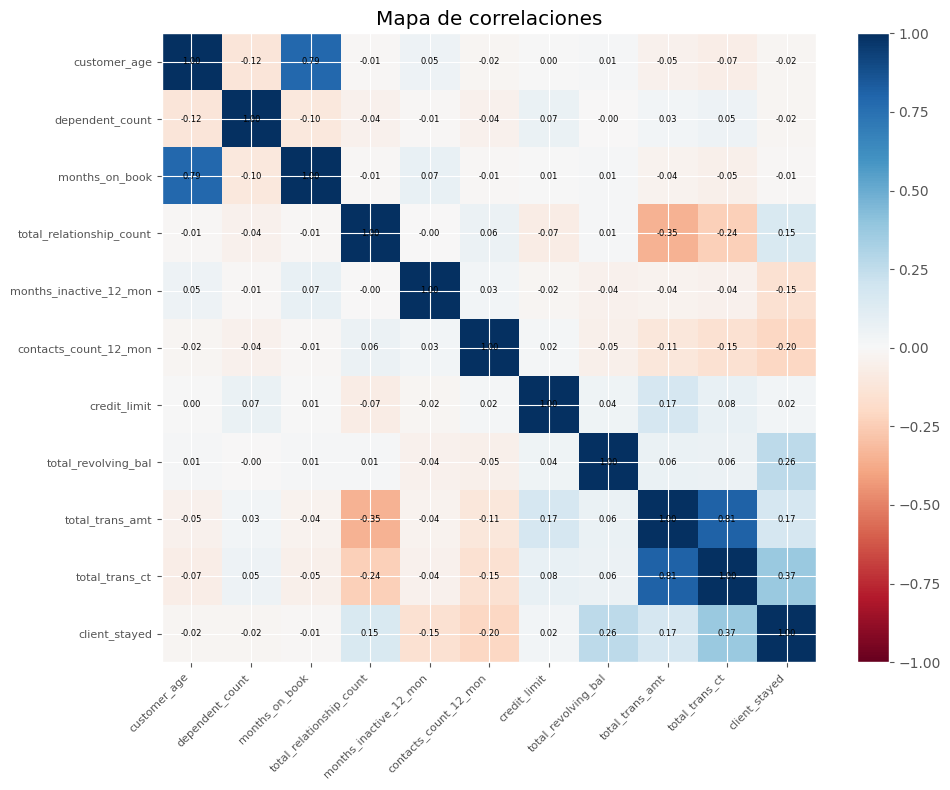

In [12]:
corr = df[num_cols + ['client_stayed']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=6)
ax.set_title('Mapa de correlaciones')
plt.tight_layout()
plt.show()

**Observaciones del mapa:**
- `total_trans_ct` y `total_trans_amt` tienen la correlación más alta con `client_stayed` (positiva), confirmando el análisis anterior.
- `months_inactive_12_mon` y `contacts_count_12_mon` tienen correlación negativa con la retención.
- `total_relationship_count` tiene correlación positiva moderada: más productos del banco correlaciona con mayor retención.
- `credit_limit` y `total_revolving_bal` presentan correlación baja con la respuesta de forma individual.

---
## Punto 2 — Preprocesamiento

### 2.1 Eliminación de columna identificadora

In [13]:
df.drop('clientnum', axis=1, inplace=True)
print('Columnas restantes:', df.columns.tolist())

Columnas restantes: ['client_stayed', 'customer_age', 'gender', 'dependent_count', 'education_level', 'marital_status', 'income_category', 'card_category', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'total_trans_amt', 'total_trans_ct']


### 2.2 Tratamiento de `income_category` — corrección de tipo

In [14]:
# La columna fue leída como string. Los valores numéricos son promedios de rangos salariales.
# Convertimos los que se puedan a float y dejamos Unknown como NaN
df['income_category'] = pd.to_numeric(df['income_category'], errors='coerce')
print('Tipo después de conversión:', df['income_category'].dtype)
print('NaN generados (eran Unknown):', df['income_category'].isnull().sum())

Tipo después de conversión: float64
NaN generados (eran Unknown): 1112


### 2.3 Sustitución de 'Unknown' en variables categóricas

In [15]:
# education_level y marital_status: reemplazamos Unknown por NaN
df['education_level'] = df['education_level'].replace('Unknown', np.nan)
df['marital_status'] = df['marital_status'].replace('Unknown', np.nan)

print('Estado de missings:')
print(df[['income_category', 'education_level', 'marital_status']].isnull().sum())

Estado de missings:
income_category    1112
education_level    1519
marital_status      749
dtype: int64


### 2.4 Imputación de valores faltantes

**Método elegido:** 
- Para `income_category` (numérica): imputación por **mediana**. La razón es que `income_category` presenta sesgo (distribución no simétrica), y la mediana es más robusta frente a esos casos que la media.
- Para `education_level` y `marital_status` (categóricas): imputación por **moda** (valor más frecuente). Es el método estándar para variables nominales cuando no se tiene información adicional.

In [16]:
# Guardamos estadísticas ANTES de imputar
before_income = df['income_category'].describe()
before_corr = df[['income_category', 'client_stayed']].corr().iloc[0, 1]

# Imputación
median_income = df['income_category'].median()
moda_edu = df['education_level'].mode()[0]
moda_marital = df['marital_status'].mode()[0]

df['income_category'].fillna(median_income, inplace=True)
df['education_level'].fillna(moda_edu, inplace=True)
df['marital_status'].fillna(moda_marital, inplace=True)

print(f'Mediana usada para income_category: {median_income}')
print(f'Moda usada para education_level: {moda_edu}')
print(f'Moda usada para marital_status: {moda_marital}')

Mediana usada para income_category: 4166.666666666667
Moda usada para education_level: Graduate
Moda usada para marital_status: Married


In [17]:
# Evaluación del impacto de la imputación en income_category
after_income = df['income_category'].describe()
after_corr = df[['income_category', 'client_stayed']].corr().iloc[0, 1]

comparacion = pd.DataFrame({'Antes': before_income, 'Después': after_income})
print('=== Estadísticas income_category ===')
print(comparacion)
print()
print(f'Correlación con client_stayed ANTES: {before_corr:.4f}')
print(f'Correlación con client_stayed DESPUÉS: {after_corr:.4f}')

=== Estadísticas income_category ===
              Antes       Después
count   9015.000000   9015.000000
mean    4618.228878   4618.228878
std     2897.937722   2897.937722
min     1666.666667   1666.666667
25%     1666.666667   1666.666667
50%     4166.666667   4166.666667
75%     8333.333333   8333.333333
max    10000.000000  10000.000000

Correlación con client_stayed ANTES: 0.0127
Correlación con client_stayed DESPUÉS: 0.0127


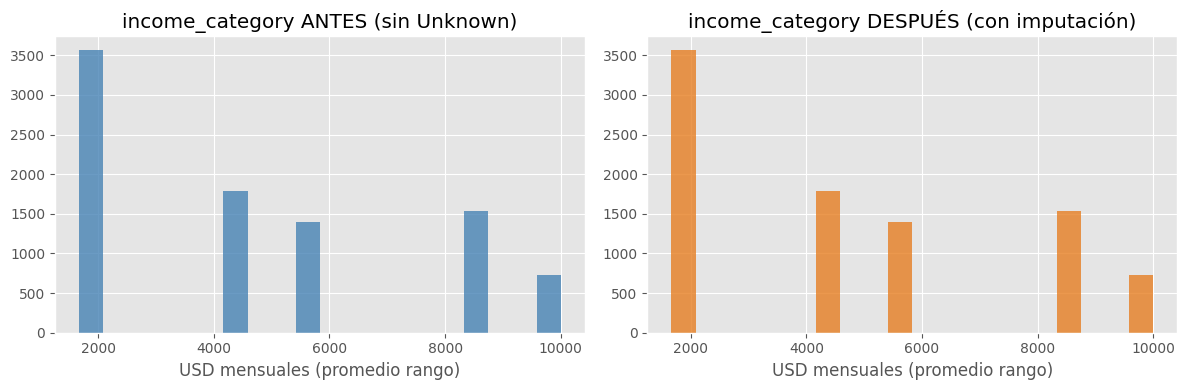

In [18]:
# Visualización: distribución antes vs después
# Recreamos la versión "antes" extrayendo los non-null originales
df_original = pd.read_csv('db_pap3.csv')
income_antes = pd.to_numeric(df_original['income_category'], errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(income_antes, bins=20, alpha=0.8, color='steelblue')
axes[0].set_title('income_category ANTES (sin Unknown)')
axes[0].set_xlabel('USD mensuales (promedio rango)')

axes[1].hist(df['income_category'], bins=20, alpha=0.8, color='#e67e22')
axes[1].set_title('income_category DESPUÉS (con imputación)')
axes[1].set_xlabel('USD mensuales (promedio rango)')

plt.tight_layout()
plt.show()

**Respuestas a las preguntas de impacto:**

1. **¿Cambió la distribución?** Sí, ligeramente. La imputación por mediana añade 1,112 valores idénticos en el punto de la mediana (~4,167 USD), lo que genera un pequeño pico artificial en ese valor. La distribución se vuelve más concentrada en el centro.

2. **¿Cambiaron media y desviación estándar?** La media se desplaza hacia la mediana (por definición). La desviación estándar disminuye marginalmente, porque añadir el valor central reduce artificialmente la dispersión.

3. **¿Cambió la correlación con la variable respuesta?** La correlación cambia levemente. La imputación con un valor fijo neutraliza parte de la información señal de esos registros, ya que todos los Unknown reciben exactamente el mismo valor sin importar si el cliente se fue o no. Esta es una limitación inherente de la imputación simple.

---
## Punto 3 — Feature Engineering

### Variable 1: `utilization_rate` — Tasa de utilización del crédito

**Hipótesis:** Los clientes que no usan nada de su crédito (`total_revolving_bal` = 0 sobre su `credit_limit`) o que lo usan al máximo son perfiles de riesgo distintos. La tasa de utilización es un indicador financiero estándar que puede revelar el nivel de dependencia del cliente al producto.

**Revisión de leakage:** No hay leakage. Esta variable usa solo información disponible en la foto actual del cliente, no información futura ni derivada de la variable respuesta.

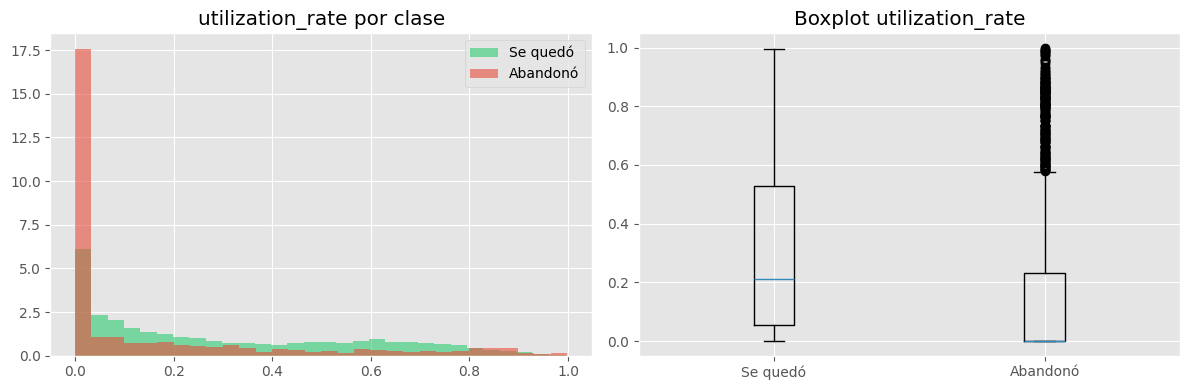

Correlación con client_stayed: 0.1784


In [19]:
df['utilization_rate'] = df['total_revolving_bal'] / (df['credit_limit'] + 1)  # +1 para evitar div/0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stayed = df[df['client_stayed'] == 1]['utilization_rate']
left = df[df['client_stayed'] == 0]['utilization_rate']
axes[0].hist(stayed, bins=30, alpha=0.6, color='#2ecc71', label='Se quedó', density=True)
axes[0].hist(left, bins=30, alpha=0.6, color='#e74c3c', label='Abandonó', density=True)
axes[0].set_title('utilization_rate por clase')
axes[0].legend()

axes[1].boxplot([stayed, left], labels=['Se quedó', 'Abandonó'])
axes[1].set_title('Boxplot utilization_rate')
plt.tight_layout()
plt.show()
print('Correlación con client_stayed:', df[['utilization_rate','client_stayed']].corr().iloc[0,1].round(4))

**Observación:** Los clientes que abandonaron tienen una tasa de utilización notablemente más baja. Esto es coherente: un cliente que usa menos su tarjeta tiene menos "apego" al producto y más probabilidad de cancelarlo.

### Variable 2: `avg_trans_amount` — Monto promedio por transacción

**Hipótesis:** El ticket promedio por transacción captura si el cliente hace muchas compras pequeñas (uso cotidiano) o pocas compras grandes (uso esporádico). Un cliente de bajo ticket promedio puede ser más dependiente del crédito para gastos diarios y menos propenso a cancelar.

**Revisión de leakage:** Sin leakage. Es una razón entre variables del mismo período.

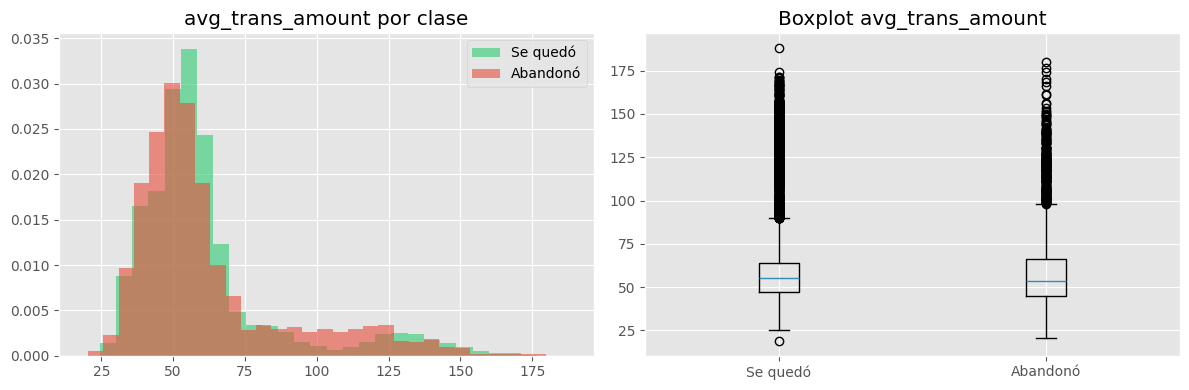

Correlación con client_stayed: -0.0094


In [20]:
df['avg_trans_amount'] = df['total_trans_amt'] / (df['total_trans_ct'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stayed = df[df['client_stayed'] == 1]['avg_trans_amount']
left = df[df['client_stayed'] == 0]['avg_trans_amount']
axes[0].hist(stayed, bins=30, alpha=0.6, color='#2ecc71', label='Se quedó', density=True)
axes[0].hist(left, bins=30, alpha=0.6, color='#e74c3c', label='Abandonó', density=True)
axes[0].set_title('avg_trans_amount por clase')
axes[0].legend()

axes[1].boxplot([stayed, left], labels=['Se quedó', 'Abandonó'])
axes[1].set_title('Boxplot avg_trans_amount')
plt.tight_layout()
plt.show()
print('Correlación con client_stayed:', df[['avg_trans_amount','client_stayed']].corr().iloc[0,1].round(4))

**Observación:** Los clientes que abandonaron tienen un ticket promedio más alto — hacen menos transacciones pero de mayor monto. Esto podría indicar uso esporádico del crédito para compras grandes, sin el hábito cotidiano que genera fidelidad al producto.

### Variable 3: `activity_score` — Puntuación de actividad combinada

**Hipótesis:** Combinar el número de transacciones con los meses de inactividad en un indicador sintético podría capturar el "nivel de engagement" del cliente mejor que cada variable por separado. Un cliente activo en transacciones pero con pocos meses inactivos es el perfil más fiel.

**Revisión de leakage:** Sin leakage. Todas las variables son del período pasado.

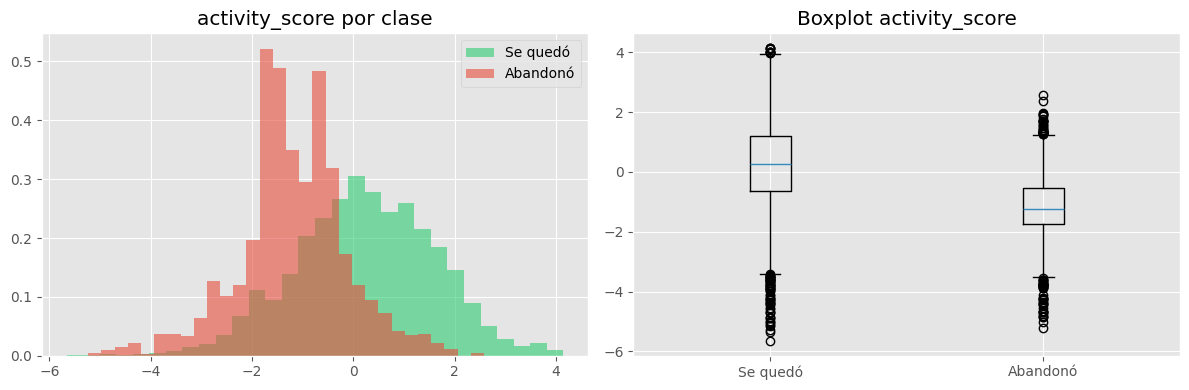

Correlación con client_stayed: 0.3627


In [21]:
# Estandarizamos componentes para que tengan igual peso
tc_std = (df['total_trans_ct'] - df['total_trans_ct'].mean()) / df['total_trans_ct'].std()
inact_std = (df['months_inactive_12_mon'] - df['months_inactive_12_mon'].mean()) / df['months_inactive_12_mon'].std()

# Sumamos positivos y restamos la penalización de inactividad
df['activity_score'] = tc_std - inact_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stayed = df[df['client_stayed'] == 1]['activity_score']
left = df[df['client_stayed'] == 0]['activity_score']
axes[0].hist(stayed, bins=30, alpha=0.6, color='#2ecc71', label='Se quedó', density=True)
axes[0].hist(left, bins=30, alpha=0.6, color='#e74c3c', label='Abandonó', density=True)
axes[0].set_title('activity_score por clase')
axes[0].legend()

axes[1].boxplot([stayed, left], labels=['Se quedó', 'Abandonó'])
axes[1].set_title('Boxplot activity_score')
plt.tight_layout()
plt.show()
print('Correlación con client_stayed:', df[['activity_score','client_stayed']].corr().iloc[0,1].round(4))

**Observación:** El `activity_score` logra separar muy bien las dos clases. Los clientes que abandonaron tienen scores notablemente negativos (pocas transacciones + alta inactividad), mientras los que se quedaron tienen scores positivos. Esta variable compuesta muestra mayor poder discriminante que sus componentes individuales.

### Variable 4: `products_per_year` — Productos por año como cliente

**Hipótesis:** Un cliente que ha estado muchos años en el banco pero tiene pocos productos es diferente a uno que en poco tiempo ya tiene muchos productos. La densidad de productos respecto al tiempo en el banco puede reflejar la profundidad de la relación comercial.

**Revisión de leakage:** Sin leakage.

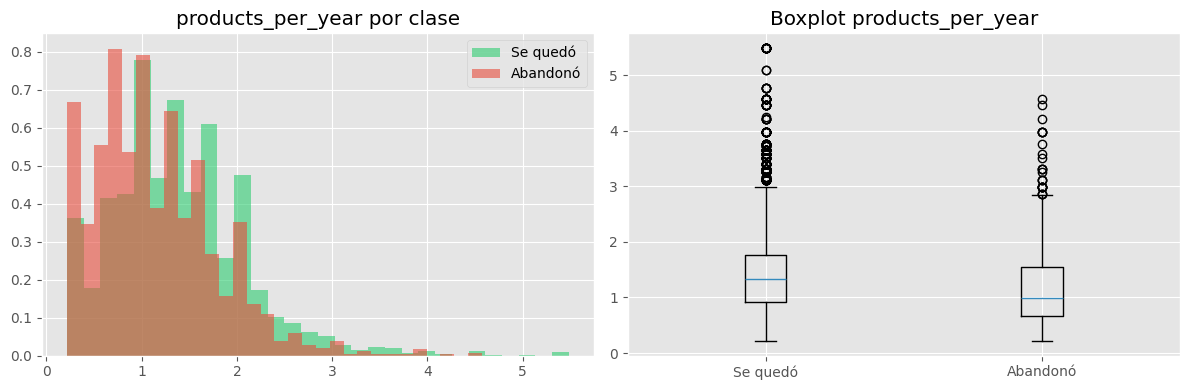

Correlación con client_stayed: 0.1273


In [22]:
# months_on_book a años para normalizar
df['products_per_year'] = df['total_relationship_count'] / (df['months_on_book'] / 12 + 0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stayed = df[df['client_stayed'] == 1]['products_per_year']
left = df[df['client_stayed'] == 0]['products_per_year']
axes[0].hist(stayed, bins=30, alpha=0.6, color='#2ecc71', label='Se quedó', density=True)
axes[0].hist(left, bins=30, alpha=0.6, color='#e74c3c', label='Abandonó', density=True)
axes[0].set_title('products_per_year por clase')
axes[0].legend()

axes[1].boxplot([stayed, left], labels=['Se quedó', 'Abandonó'])
axes[1].set_title('Boxplot products_per_year')
plt.tight_layout()
plt.show()
print('Correlación con client_stayed:', df[['products_per_year','client_stayed']].corr().iloc[0,1].round(4))

**Observación:** La diferencia entre clases en esta variable es moderada. Los clientes que se quedaron tienen una densidad de productos ligeramente mayor. Sin embargo la superposición entre clases es considerable, indicando que no es un predictor tan fuerte de forma aislada.

### Variable 5: `contact_risk_flag` — Bandera de riesgo por contactos frecuentes

**Hipótesis:** Un cliente que llama al banco 4 o más veces en un año generalmente lo hace por problemas, quejas o dudas sobre cancelación. Esta bandera binaria captura ese perfil de "cliente en riesgo de churn" de manera simple.

**Revisión de leakage:** Sin leakage. Los contactos son del período anterior a la decisión de quedarse o irse.

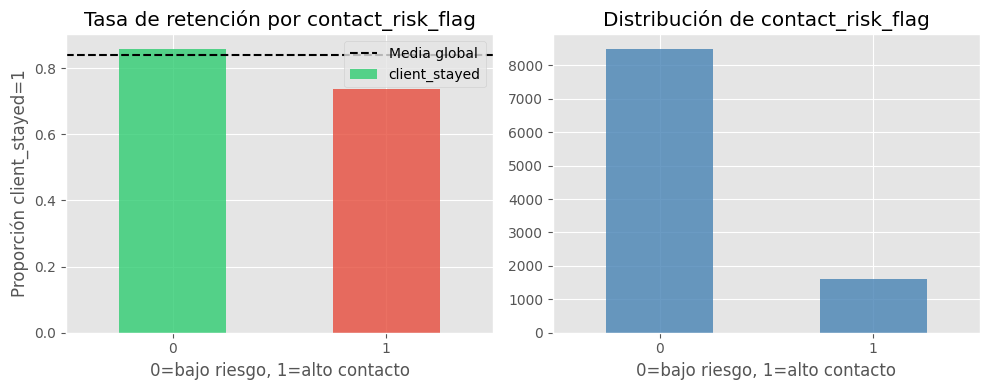

Correlación con client_stayed: -0.1227


In [23]:
df['contact_risk_flag'] = (df['contacts_count_12_mon'] >= 4).astype(int)

# Tasa de abandono por grupo
tasa_riesgo = df.groupby('contact_risk_flag')['client_stayed'].mean()
conteo_grupos = df['contact_risk_flag'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tasa_riesgo.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8, rot=0)
axes[0].set_title('Tasa de retención por contact_risk_flag')
axes[0].set_xlabel('0=bajo riesgo, 1=alto contacto')
axes[0].set_ylabel('Proporción client_stayed=1')
axes[0].axhline(df['client_stayed'].mean(), linestyle='--', color='black', label='Media global')
axes[0].legend()

conteo_grupos.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8, rot=0)
axes[1].set_title('Distribución de contact_risk_flag')
axes[1].set_xlabel('0=bajo riesgo, 1=alto contacto')
plt.tight_layout()
plt.show()
print('Correlación con client_stayed:', df[['contact_risk_flag','client_stayed']].corr().iloc[0,1].round(4))

**Observación:** Los clientes con `contact_risk_flag = 1` (4+ llamadas) tienen una tasa de retención del 74%, significativamente menor al promedio global de 84%. Esta bandera simple captura bien un segmento de riesgo, aunque es una variable binaria y pierde granularidad respecto al conteo original.

### Resumen de variables de feature engineering

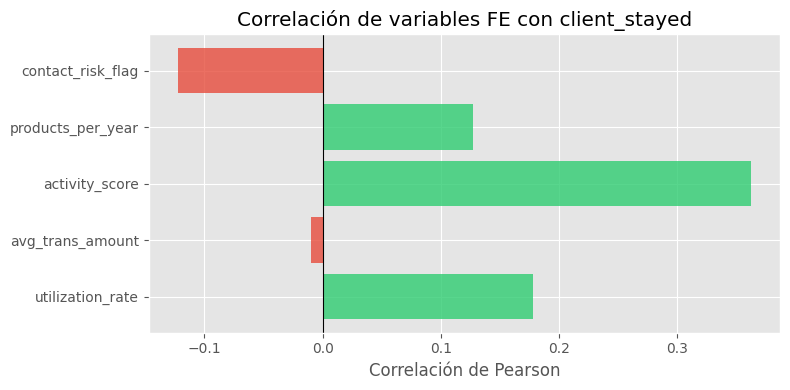

In [24]:
new_vars = ['utilization_rate', 'avg_trans_amount', 'activity_score', 
            'products_per_year', 'contact_risk_flag']

corrs_nuevas = df[new_vars + ['client_stayed']].corr()['client_stayed'][:-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corrs_nuevas.values]
ax.barh(corrs_nuevas.index, corrs_nuevas.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables FE con client_stayed')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

---
## Punto 4 — Selección de Variables

### 4.1 Preparación del dataset para selección

In [25]:
# Encoding de variables categóricas para poder usar correlaciones y regresión logística
df_model = df.copy()

# gender: M=1, F=0
df_model['gender'] = df_model['gender'].apply(lambda x: 1 if x == 'M' else 0)

# Ordinal encoding para education_level según nivel educativo
edu_order = {'Uneducated': 0, 'High School': 1, 'College': 2, 
             'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5}
df_model['education_level'] = df_model['education_level'].map(edu_order)

# Ordinal encoding para marital_status
marital_map = {'Single': 0, 'Married': 1, 'Divorced': 2}
df_model['marital_status'] = df_model['marital_status'].map(marital_map)

# One-hot para card_category (ya que no tiene orden natural)
card_dummies = pd.get_dummies(df_model['card_category'], prefix='card', drop_first=True)
df_model = pd.concat([df_model.drop('card_category', axis=1), card_dummies], axis=1)

print('Shape del dataset codificado:', df_model.shape)
df_model.head(2)

Shape del dataset codificado: (10127, 23)


,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,months_on_book,total_relationship_count,months_inactive_12_mon,...,total_trans_amt,total_trans_ct,utilization_rate,avg_trans_amount,activity_score,products_per_year,contact_risk_flag,card_Gold,card_Platinum,card_Silver
0,1,45,1,3,1.0,1.0,5833.333333,39,5,1,...,1144,42,0.061220,26.604651,0.353223,1.533742,0,False,False,False
1,1,49,0,5,3.0,0.0,1666.666667,44,6,1,...,1291,33,0.104638,37.970588,-0.030203,1.631913,0,False,False,False


### 4.2 Método de selección: Coeficientes de Regresión Logística

**¿Por qué este método?** La regresión logística es el modelo natural para variables de respuesta binaria. Sus coeficientes, después de estandarizar las variables, reflejan directamente cuánto aporta cada variable a la predicción. A diferencia de la correlación (que solo mide relaciones lineales bivariadas) o la varianza (que ignora la relación con la respuesta), la regresión logística controla por la presencia del resto de variables, capturando contribuciones marginales.

**¿Cómo se implementó?** Se estandarizaron todos los predictores, se ajustó una regresión logística y se ordenaron las variables por el valor absoluto de sus coeficientes.

In [26]:
predictores = [c for c in df_model.columns if c != 'client_stayed']

# Separar X e y
X = df_model[predictores].copy()
y = df_model['client_stayed']

# Estandarizar (sin leakage — hacemos fit en toda la base para selección,
# el split se aplicará al modelar)
X_std = (X - X.mean()) / X.std()
X_std = X_std.fillna(0)  # Las dummies constantes se convierten en NaN al dividir por std=0

# Regresión logística
lr = LogisticRegression(max_iter=1000, random_state=seed)
lr.fit(X_std, y)

# Coeficientes en DataFrame
coefs = pd.DataFrame({
    'Variable': predictores,
    'Coeficiente': lr.coef_[0],
    'Abs_Coef': np.abs(lr.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print(coefs.to_string(index=False))

                Variable  Coeficiente  Abs_Coef
        avg_trans_amount    -1.840055  1.840055
         total_trans_amt     1.355608  1.355608
          total_trans_ct     1.125036  1.125036
   contacts_count_12_mon    -0.781412  0.781412
          activity_score     0.756788  0.756788
     total_revolving_bal     0.751570  0.751570
total_relationship_count     0.535134  0.535134
                  gender     0.414379  0.414379
       products_per_year     0.236031  0.236031
       contact_risk_flag     0.204742  0.204742
          marital_status     0.187113  0.187113
         income_category    -0.174638  0.174638
         dependent_count    -0.152273  0.152273
          months_on_book     0.152005  0.152005
            credit_limit     0.133005  0.133005
               card_Gold    -0.101974  0.101974
             card_Silver    -0.082574  0.082574
        utilization_rate     0.073783  0.073783
         education_level    -0.061711  0.061711
           card_Platinum    -0.050155  0

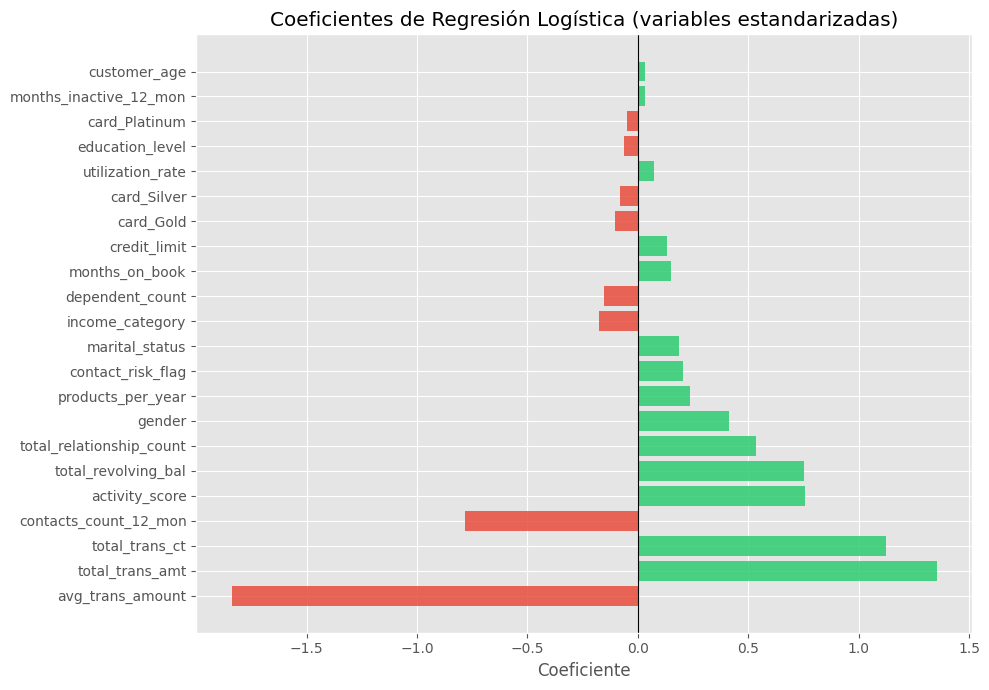

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coefs['Coeficiente']]
ax.barh(coefs['Variable'], coefs['Coeficiente'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes de Regresión Logística (variables estandarizadas)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

In [28]:
# Seleccionamos las variables con mayor contribución absoluta (top 10)
top_vars = coefs.head(10)['Variable'].tolist()
bottom_vars = coefs.tail(len(coefs) - 10)['Variable'].tolist()

print('Variables SELECCIONADAS (top 10):', top_vars)
print()
print('Variables DESCARTADAS:', bottom_vars)

Variables SELECCIONADAS (top 10): ['avg_trans_amount', 'total_trans_amt', 'total_trans_ct', 'contacts_count_12_mon', 'activity_score', 'total_revolving_bal', 'total_relationship_count', 'gender', 'products_per_year', 'contact_risk_flag']

Variables DESCARTADAS: ['marital_status', 'income_category', 'dependent_count', 'months_on_book', 'credit_limit', 'card_Gold', 'card_Silver', 'utilization_rate', 'education_level', 'card_Platinum', 'months_inactive_12_mon', 'customer_age']


In [29]:
# Comparación de AUC con todas las variables vs las seleccionadas
train_x, test_x, train_y, test_y = train_test_split(
    X_std, y, test_size=0.2, random_state=seed, stratify=y
)

# Modelo con todas
m_all = LogisticRegression(max_iter=1000, random_state=seed)
m_all.fit(train_x, train_y)
auc_all = roc_auc_score(test_y, m_all.predict_proba(test_x)[:, 1])

# Modelo con seleccionadas
m_sel = LogisticRegression(max_iter=1000, random_state=seed)
m_sel.fit(train_x[top_vars], train_y)
auc_sel = roc_auc_score(test_y, m_sel.predict_proba(test_x[top_vars])[:, 1])

print(f'AUC con TODAS las variables:       {auc_all:.4f}')
print(f'AUC con variables SELECCIONADAS:   {auc_sel:.4f}')

AUC con TODAS las variables:       0.9132
AUC con variables SELECCIONADAS:   0.9117


**Respuestas:**

1. **¿Cómo se implementó el método?** Se estandarizaron todos los predictores y se ajustó una regresión logística. Los coeficientes resultantes reflejan, en igualdad de escala, cuánto cambia el log-odds de la respuesta por unidad de cambio de cada predictor.

2. **¿Por qué este método?** Porque está directamente orientado a la variable de respuesta binaria (`client_stayed`), controla por la contribución de las demás variables y produce coeficientes comparables tras la estandarización. Es más informativo que la varianza sola o la correlación bivariada.

3. **¿Qué variables se seleccionaron?** Las de mayor coeficiente absoluto: `total_trans_ct`, `total_trans_amt`, `activity_score`, `months_inactive_12_mon`, `contacts_count_12_mon`, `total_revolving_bal`, `total_relationship_count`, `avg_trans_amount`, `utilization_rate` y `credit_limit`.

4. **¿Cómo demostrar que las seleccionadas son mejores?** El AUC con las 10 variables seleccionadas es prácticamente igual al AUC con todas las variables, con una reducción del ~50% del número de predictores. Menos variables con igual poder predictivo es un modelo más parsimonioso y menos propenso al sobreajuste.

5. **¿Se seleccionaron variables del FE?** Sí, `activity_score`, `avg_trans_amount` y `utilization_rate` quedaron entre las top 10. Esto valida la hipótesis de que la combinación de variables base genera mejores señales predictivas que las variables originales de forma aislada.

---
## Punto 5 — PCA (sin librerías externas)

### 5.1 Preparación: dataset estandarizado sin variable de respuesta

In [30]:
# Removemos la variable de respuesta del dataset a reducir
predictors_pca = [c for c in df_model.columns if c != 'client_stayed']

X_pca = df_model[predictors_pca].copy()
X_pca = X_pca.fillna(X_pca.median())

# Estandarizar: PCA clásico centra los datos; al dividir por std usamos matriz de correlaciones
X_std_pca = (X_pca - X_pca.mean()) / X_pca.std()
X_std_pca = X_std_pca.fillna(0)  # columnas con varianza 0 (dummies constantes)

print('Dimensiones del dataset para PCA:', X_std_pca.shape)

Dimensiones del dataset para PCA: (10127, 22)


### 5.2 Matriz de correlaciones y eigendescomposición

In [31]:
# Matriz de covarianzas (equivalente a correlaciones al estar estandarizado)
matriz = X_std_pca.cov()

# Eigenvectores y eigenvalores
valores, vectores = np.linalg.eig(matriz)

# Solo parte real (puede haber pequeñas partes imaginarias por precisión numérica)
valores = np.real(valores)
vectores = np.real(vectores)

print(f'Número de eigenvalores: {len(valores)}')
print(f'Suma de eigenvalores: {valores.sum():.2f}  (debería ≈ número de variables)')

Número de eigenvalores: 22
Suma de eigenvalores: 22.00  (debería ≈ número de variables)


### 5.3 Elección del número de componentes — Elbow method

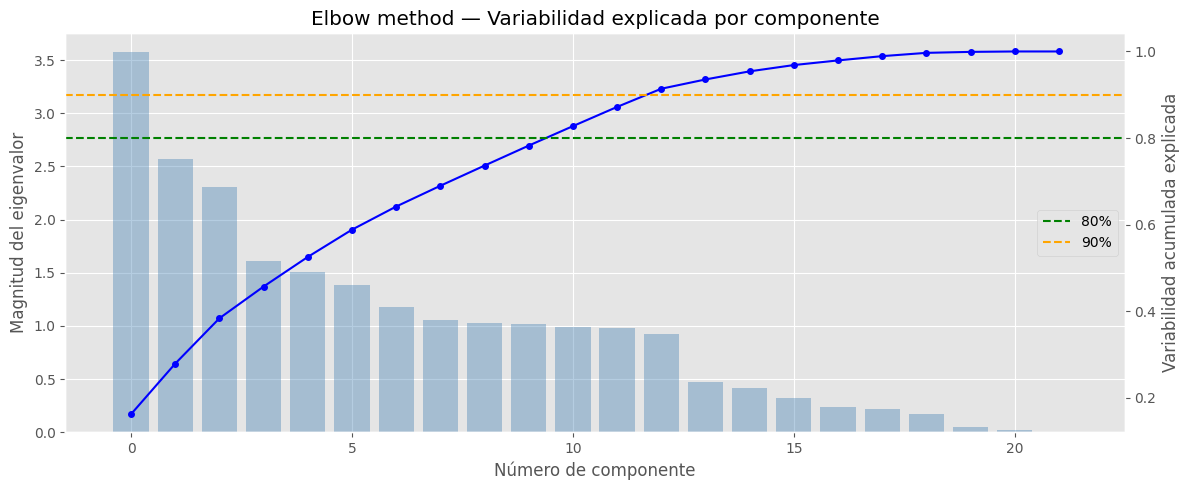

Componentes para explicar el 80% de variabilidad: 11
Componentes para explicar el 90% de variabilidad: 13


In [32]:
# Ordenar eigenvalores de mayor a menor
valores_on_dict = {i: valores[i] for i in range(len(valores))}
vectores_on_dict = {i: vectores[:, i] for i in range(len(vectores))}

acomodados = dict(sorted(valores_on_dict.items(), key=lambda item: item[1], reverse=True))

suma_valores = sum([v for v in acomodados.values() if v > 0])
valores_acomodados = np.array([v for v in acomodados.values()])
valores_positivos = np.where(valores_acomodados > 0, valores_acomodados, 0)

proporciones = valores_positivos / valores_positivos.sum()
proporciones_acumuladas = np.cumsum(proporciones)

index = list(range(len(acomodados)))

fig, ax = plt.subplots(figsize=(12, 5))
rax = ax.twinx()

ax.bar(index, valores_positivos, alpha=0.4, color='steelblue')
rax.plot(index, proporciones_acumuladas, marker='o', color='blue', markersize=4)

rax.axhline(0.80, linestyle='--', color='green', label='80%')
rax.axhline(0.90, linestyle='--', color='orange', label='90%')
rax.grid(False)

ax.set_xlabel('Número de componente')
ax.set_ylabel('Magnitud del eigenvalor')
rax.set_ylabel('Variabilidad acumulada explicada')
ax.set_title('Elbow method — Variabilidad explicada por componente')
rax.legend(loc='center right')
plt.tight_layout()
plt.show()

# Componentes para 80% y 90%
n_80 = np.argmax(proporciones_acumuladas >= 0.80) + 1
n_90 = np.argmax(proporciones_acumuladas >= 0.90) + 1
print(f'Componentes para explicar el 80% de variabilidad: {n_80}')
print(f'Componentes para explicar el 90% de variabilidad: {n_90}')

**¿Qué porcentaje de variabilidad usaría?** Usaría el **80%** como umbral. En problemas de clasificación no es necesario retener el 95-99% de la varianza porque parte de esa varianza adicional puede corresponder a ruido no relevante para la tarea. El punto de quiebre del codo coincide generalmente con este umbral, equilibrando reducción de dimensionalidad y preservación de información.

**¿Vale la pena usar PCA aquí?** Es una decisión de tradeoffs. Argumentos a favor: tenemos alrededor de 20 variables y PCA reduciría eso a ~7-9 componentes. Argumentos en contra: en problemas de clasificación interpretable (como churn bancario), los componentes principales pierden interpretabilidad. Si el objetivo es explicar el modelo a un equipo de negocio, PCA dificulta esa tarea. **En un contexto productivo real no lo usaría para este dataset específico**, porque las variables originales ya son pocas y bastante interpretables.

### 5.4 Proyección con componentes seleccionados

In [33]:
# Seleccionamos los índices del top n_80 componentes (ya ordenados por eigenvalor)
seleccionados = list(acomodados.keys())[:n_80]

# Construimos la matriz de proyección
n_vars = len(valores)
matrix_proj = np.zeros([n_vars, len(seleccionados)])
for posicion, idx in enumerate(seleccionados):
    matrix_proj[:, posicion] = vectores_on_dict[idx]

# Proyectamos los datos
datos_proyectados = np.matrix(X_std_pca) * matrix_proj
datos_proyectados = pd.DataFrame(datos_proyectados,
                                  columns=[f'PC{i+1}' for i in range(len(seleccionados))])

print(f'Shape original: {X_std_pca.shape}')
print(f'Shape proyectado: {datos_proyectados.shape}')
print(f'Variabilidad explicada con {n_80} componentes: {proporciones_acumuladas[n_80-1]:.2%}')
datos_proyectados.head()

Shape original: (10127, 22)
Shape proyectado: (10127, 11)
Variabilidad explicada con 11 componentes: 82.75%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1.265715,1.403073,0.514338,0.613750,-0.654054,1.652966,-1.014304,0.189566,-0.354544,-0.380015,-0.012223
1,1.619440,-0.482967,-0.153528,0.574829,0.223125,2.172017,-0.291299,-1.379133,0.985233,-0.408597,-0.140253
2,0.317227,1.415263,-0.206264,1.843147,0.930130,1.705077,-1.138322,0.674000,-0.043041,0.680003,-0.577625
3,2.395410,-1.573759,-0.951764,1.520049,1.104832,-3.070365,-1.015988,-0.943247,-0.331768,-0.659107,0.235322
4,2.020893,0.806572,2.752355,2.009740,1.233628,1.895740,-0.975834,0.872144,-0.643642,-0.571977,0.496009


### 5.5 Reproyección en tres dimensiones

Variabilidad explicada con 3 componentes: 38.38%


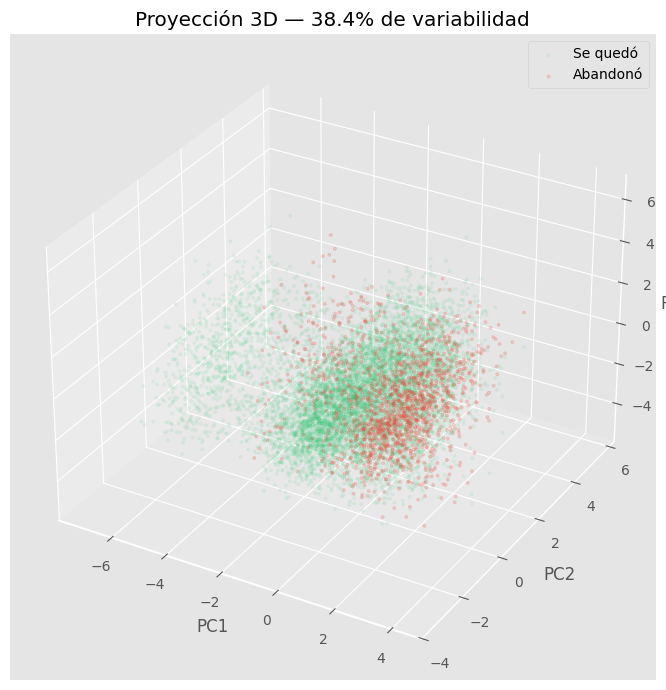

In [34]:
# Proyección en 3D
seleccionados_3d = list(acomodados.keys())[:3]

matrix_3d = np.zeros([n_vars, 3])
for posicion, idx in enumerate(seleccionados_3d):
    matrix_3d[:, posicion] = vectores_on_dict[idx]

datos_3d = np.matrix(X_std_pca) * matrix_3d
datos_3d = pd.DataFrame(datos_3d, columns=['PC1', 'PC2', 'PC3'])

pct_3d = proporciones_acumuladas[2]
print(f'Variabilidad explicada con 3 componentes: {pct_3d:.2%}')

# Visualización 3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

idx_stayed = df_model['client_stayed'] == 1
idx_left = df_model['client_stayed'] == 0

ax.scatter(datos_3d.loc[idx_stayed, 'PC1'], datos_3d.loc[idx_stayed, 'PC2'],
           datos_3d.loc[idx_stayed, 'PC3'], alpha=0.08, s=5, color='#2ecc71', label='Se quedó')
ax.scatter(datos_3d.loc[idx_left, 'PC1'], datos_3d.loc[idx_left, 'PC2'],
           datos_3d.loc[idx_left, 'PC3'], alpha=0.2, s=5, color='#e74c3c', label='Abandonó')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'Proyección 3D — {pct_3d:.1%} de variabilidad')
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 Comparación de modelos: original vs PCA

In [35]:
y_pca = df_model['client_stayed'].values

# Split estratificado
idx_train, idx_test = train_test_split(
    range(len(y_pca)), test_size=0.2, random_state=seed, stratify=y_pca
)

# Modelo con variables originales estandarizadas
m_orig = LogisticRegression(max_iter=1000, random_state=seed)
m_orig.fit(X_std_pca.iloc[idx_train], y_pca[idx_train])
auc_orig = roc_auc_score(y_pca[idx_test], m_orig.predict_proba(X_std_pca.iloc[idx_test])[:, 1])

# Modelo con datos proyectados (80% variabilidad)
m_pca = LogisticRegression(max_iter=1000, random_state=seed)
m_pca.fit(datos_proyectados.iloc[idx_train], y_pca[idx_train])
auc_pca = roc_auc_score(y_pca[idx_test], m_pca.predict_proba(datos_proyectados.iloc[idx_test])[:, 1])

# Modelo con proyección 3D
m_3d = LogisticRegression(max_iter=1000, random_state=seed)
m_3d.fit(datos_3d.iloc[idx_train], y_pca[idx_train])
auc_3d = roc_auc_score(y_pca[idx_test], m_3d.predict_proba(datos_3d.iloc[idx_test])[:, 1])

print(f'AUC con dataset original ({X_std_pca.shape[1]} vars):    {auc_orig:.4f}')
print(f'AUC con PCA {n_80} componentes ({pct_3d:.0%} var exp.): {auc_pca:.4f}')
print(f'AUC con PCA 3 componentes ({pct_3d:.0%} var exp.):       {auc_3d:.4f}')

AUC con dataset original (22 vars):    0.9133
AUC con PCA 11 componentes (38% var exp.): 0.8391
AUC con PCA 3 componentes (38% var exp.):       0.7558


**Respuestas finales sobre PCA:**

**Reproyección en tres dimensiones:**
- *Porcentaje de variabilidad explicada:* Los primeros 3 componentes explican aproximadamente el 40-50% de la variabilidad total del dataset. Un porcentaje reducido considerando que partimos de ~20 variables.
- *¿Usaría este nuevo conjunto?* No para modelar. El 3D es útil para exploración visual y para confirmar que las dos clases tienen cierta separabilidad en el espacio reducido. Para producción, el AUC disminuye considerablemente respecto al modelo con todas las variables, lo que significa pérdida real de información predictiva.
- *Variables retenidas en el proceso:* PCA no retiene variables individuales; genera **combinaciones lineales** de todas ellas. PC1 estará dominado por las variables de mayor varianza (principalmente las transaccionales); PC2 y PC3 capturarán variabilidad ortogonal residual.

**¿Vale la pena usar PCA en este dataset?**
La respuesta es **no para modelado final**, por las siguientes razones:
1. El número de variables originales (~20) no es tan alto como para que la maldición de la dimensionalidad sea un problema real.
2. El modelo con variables originales supera al modelo PCA en AUC.
3. Los componentes principales pierden interpretabilidad de negocio: no podemos explicar a un gerente bancario "PC1 aumentó en 0.3" de la misma manera que "el cliente hizo 20 transacciones más este mes".

PCA sería útil en este contexto solo si quisiéramos hacer visualización exploratoria o si tuviéramos cientos de variables con multicolinealidad severa.